# ISS Projekt 2023/24

Honza Pavlus, Honza Brukner a Honza Černocký, ÚPGM FIT VUT

6.11. 2023



## 1. Úvod

V projektu budete pracovat se biomedicínskými signály a to konkrétně se signálem elektrokardiogramu EKG. Vyzkoušíte si filtraci tohoto druhu signálu, abyste dostali krásné EKG křivky, které můžete vidět ve filmech. Dále si zkusíte vybudovat jednoduchý, ale účinný detektor QRS a ti, kteří se vrhnou i na bonusový úkol, si zkusí odhalit srdeční patologii. K dispozici dostanete každý 3 nahrávky jednokanálového EKG signálu, jeden zdravý a dva s různými patologiemi.

Projekt je nejlépe možno řešit v Python-u a to přímo v dodaném Python notebooku, který si můžete zkopírovat do vlastního Google Colabu. Projekt je také možno řešit v Matlab-u, Octave, Julii, jazyce C, Java nebo v libovolném jiném programovacím či skriptovacím jazyce. Je možné použít libovolné knihovny. Projekt se nezaměřuje na “krásu programování”, není tedy nutné mít vše úhledně zabalené do okomentovaných funkcí (samozřejmě se ale okomentovaný kód lépe opravuje a to hlavně v případě podivných výsledků), ošetřené všechny chybové stavy, atd. Důležitý je výsledek.

**Vaši práci odevzdáváte vyexportovanou do dvou souborů: (1) do PDF souboru login.pdf, (2) do Python notebooku login.ipynb. PDF musí obsahovat výsledky prokazatelně vytvořené Vaším kódem.** V případě řešení projektu v jiném jazyce nebo prostředí než v dodaném Python notebooku, je prvním souborem protokol v PDF, druhý soubor je archiv s Vaším kódem. Ten musí být spustitelný na standardní fakultní distribuci Windows nebo Linuxu.

## 3. Vstup
Pro řešení projektu má každý student/ka k disposici osobní soubor se  zdravým signálem (sinusovým rytmem): ***login.wav***, kde login je váš xlogin popřípadě VUT číslo (pro studenty FSI). Dále jsou k disposici  ještě další dva signály: ***FIS.wav*** a ***KES.wav***. První signál obsahuje fibrilaci a druhý komorovou extrasystolu. Tyhle dva soubory jsou pro všechny společné a využijete je při řešení bonusového úkolu.

In [1]:
%matplotlib inline
#Načtení Vašeho signálu - xlogin99 nahraďte Vaším loginem
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import find_peaks

!wget https://www.fit.vutbr.cz/study/courses/ISS/public/proj2023-24/xondre16.wav
!wget https://www.fit.vutbr.cz/study/courses/ISS/public/proj2023-24/FIB.wav
!wget https://www.fit.vutbr.cz/study/courses/ISS/public/proj2023-24/KES.wav

x, fs = sf.read("xondre16.wav")


--2023-12-17 22:54:42--  https://www.fit.vutbr.cz/study/courses/ISS/public/proj2023-24/xondre16.wav
Resolving www.fit.vutbr.cz (www.fit.vutbr.cz)... 147.229.9.23, 2001:67c:1220:809::93e5:917
Connecting to www.fit.vutbr.cz (www.fit.vutbr.cz)|147.229.9.23|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10044 (9.8K) [audio/x-wav]
Saving to: ‘xondre16.wav’

xondre16.wav        100%[===================>]   9.81K  --.-KB/s    in 0s      

2023-12-17 22:54:45 (81.4 MB/s) - ‘xondre16.wav’ saved [10044/10044]

--2023-12-17 22:54:45--  https://www.fit.vutbr.cz/study/courses/ISS/public/proj2023-24/FIB.wav
Resolving www.fit.vutbr.cz (www.fit.vutbr.cz)... 147.229.9.23, 2001:67c:1220:809::93e5:917
Connecting to www.fit.vutbr.cz (www.fit.vutbr.cz)|147.229.9.23|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10044 (9.8K) [audio/x-wav]
Saving to: ‘FIB.wav’

FIB.wav             100%[===================>]   9.81K  --.-KB/s    in 0s      

2023-12-17 22:

## 4. Úkoly



### 4.1. [2.5b] Nahrání a zobrazení EKG signálu

Nezapomeňte na popisy os u jednotlivých grafů.

 a) [1b] Nahrajte EKG signál login.wav, vyberte 5-sekundový úsek a zobrazte ho v časové doméně. Pro nahrání signálu použijte knihovny numpy a soundfile.

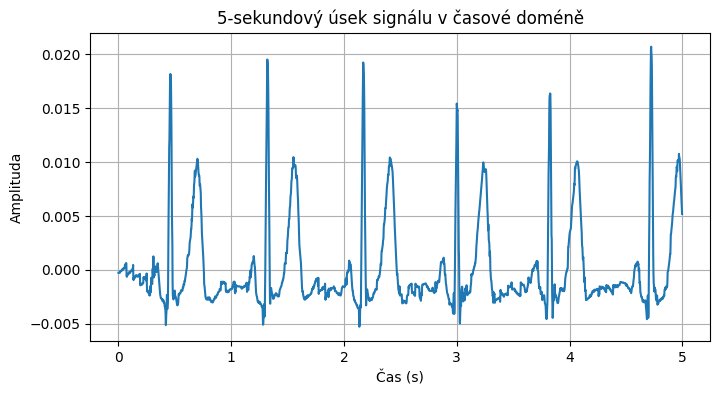

In [2]:
%matplotlib inline
###################################################################################################

# Výběr segmentu délky 5 sekund ze signálu
segment = x[:int(5 * fs)]

# Vytvoření časové osy pro segment
time = np.arange(segment.size) / fs

# Zobrazení vybraného 5-sekundového úseku v časové doméně
plt.figure(figsize=(8, 4))
plt.plot(time, segment)
plt.title('5-sekundový úsek signálu v časové doméně')
plt.xlabel('Čas (s)')
plt.ylabel('Amplituda')
plt.grid(True)
plt.show()

###################################################################################################

b) [1b] Spočítejte spektrum z 5 sekundového úseku nahraného signálu a zobrazte jej.

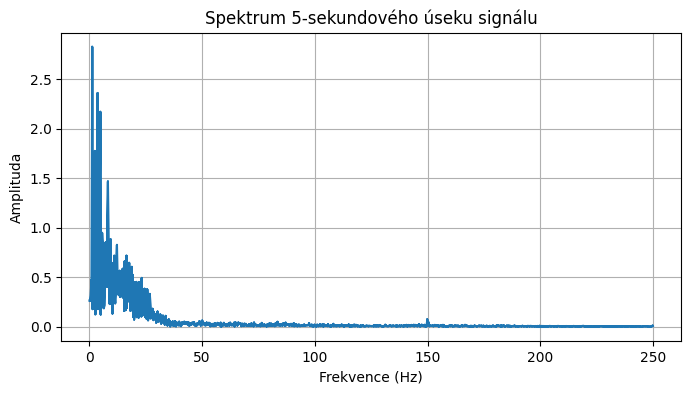

In [3]:
%matplotlib inline
###################################################################################################

# Výpočet diskrétní Fourierovy transformace (DFT)
X = np.fft.fft(segment)

# Výpočet frekvenční osy odpovídající DFT
freq = np.fft.fftfreq(len(X), 1 / fs)

# Vykreslení spektra 5-sekundového úseku signálu
plt.figure(figsize=(8, 4))
plt.plot(np.abs(freq), np.abs(X))
plt.title('Spektrum 5-sekundového úseku signálu')
plt.xlabel('Frekvence (Hz)')
plt.ylabel('Amplituda')
plt.grid(True)
plt.show()

###################################################################################################

 c) [0.5b] Ve spektru vidíte rušení na 50Hz nebo 60Hz a jejich harmonických frekvencích. Vysvětlete, čím je způsobeno.

Rušení na 50 Hz nebo 60 Hz a jejich harmonické frekvence jsou často způsobeny elektrickým systémem napájení. V závislosti na geografické lokalitě se používají různé standardy pro frekvenci elektrické sítě.

### 4.2. [3b] Převzorkujte nahraný signál



a) [2b] Převzorkujte signál na vzorkovací frekvenci 100 Hz, nezapomeňte na filtr pro antialiasing. Můžete například odstranit část spektra od $\frac{Fs}{2}$ nebo použít filtr dolní propusti.

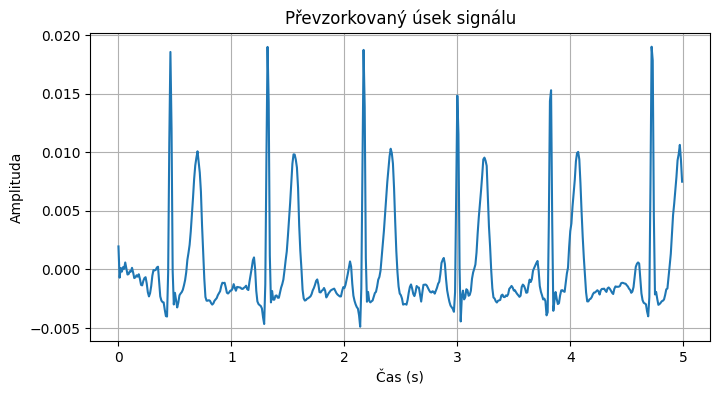

In [4]:
%matplotlib inline
###################################################################################################

# Filtr pro antialiasing
cutoff = 40 / (fs / 2)
b, a = signal.butter(4, cutoff, btype='low')

# Aplikace filtru na segment
filtered_segment = signal.filtfilt(b, a, segment)

# Převzorkování signálu na vzorkovací frekvenci 100 Hz
resampled_fs = 100
resampled_segment = signal.resample(filtered_segment, int(len(filtered_segment) * resampled_fs / fs))

# Vytvoření časové osy pro nový signál
resampled_time = np.arange(len(resampled_segment)) / resampled_fs

# Zobrazení převzorkovaného úseku v časové doméně
plt.figure(figsize=(8, 4))
plt.plot(resampled_time, resampled_segment)
plt.title('Převzorkovaný úsek signálu')
plt.xlabel('Čas (s)')
plt.ylabel('Amplituda')
plt.grid(True)
plt.show()

###################################################################################################

b) [1b] Zobrazte 5 sekundový úsek původního a převzorkovaného signálu v časové doméně a zobrazte i jejich spektra.

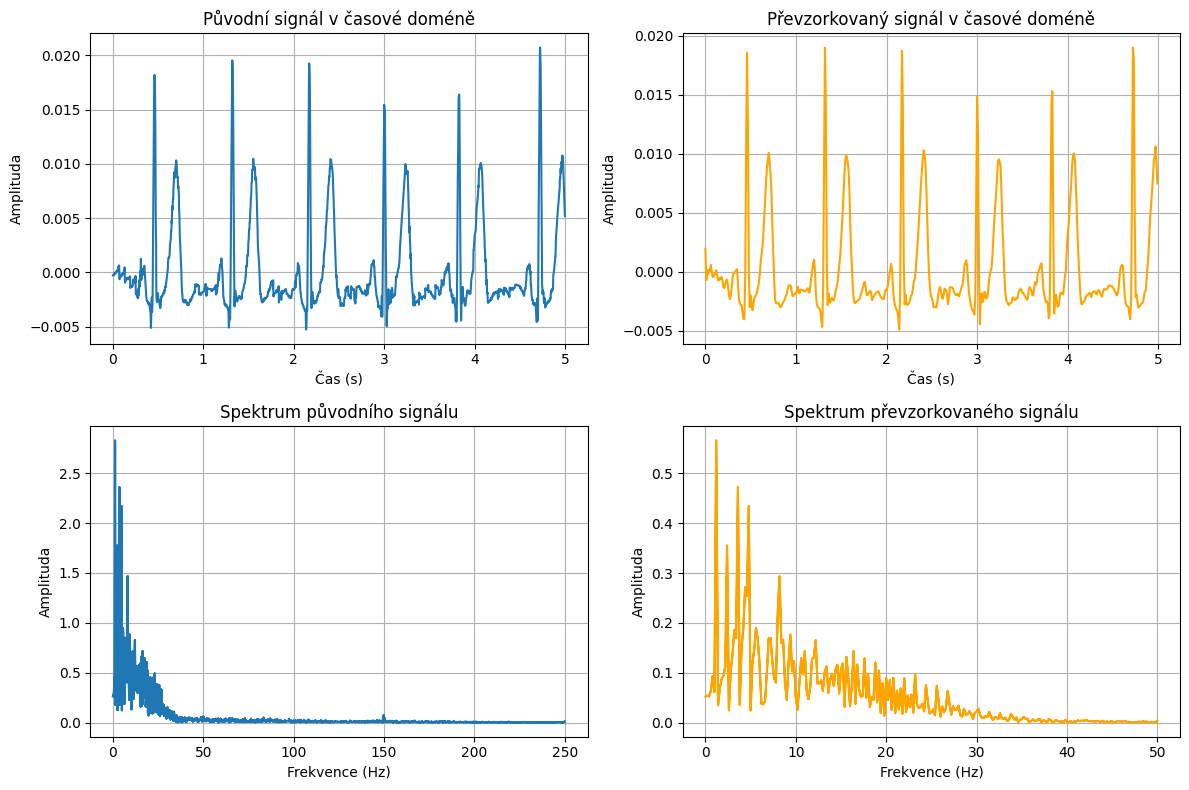

In [5]:
%matplotlib inline
###################################################################################################

# Výpočet spektra převzorkovaného signálu
resampled_spectrum = np.fft.fft(resampled_segment)
frequencies = np.fft.fftfreq(len(resampled_spectrum), 1 / resampled_fs)

# Plot obou sad grafů vedle sebe
plt.figure(figsize=(12, 8))

# Vykreslení původního signálu v časové doméně
plt.subplot(2, 2, 1)
plt.plot(time, segment)
plt.title('Původní signál v časové doméně')
plt.xlabel('Čas (s)')
plt.ylabel('Amplituda')
plt.grid(True)

# Vykreslení spektra původního signálu
plt.subplot(2, 2, 3)
plt.plot(np.abs(freq), np.abs(X))
plt.title('Spektrum původního signálu')
plt.xlabel('Frekvence (Hz)')
plt.ylabel('Amplituda')
plt.grid(True)

# Vykreslení převzorkovaného signálu v časové doméně
plt.subplot(2, 2, 2)
plt.plot(resampled_time, resampled_segment, color = 'orange')
plt.title('Převzorkovaný signál v časové doméně')
plt.xlabel('Čas (s)')
plt.ylabel('Amplituda')
plt.grid(True)

# Vykreslení spektra převzorkovaného signálu
plt.subplot(2, 2, 4)
plt.plot(np.abs(frequencies), np.abs(resampled_spectrum), color = 'orange')
plt.title('Spektrum převzorkovaného signálu')
plt.xlabel('Frekvence (Hz)')
plt.ylabel('Amplituda')
plt.grid(True)

plt.tight_layout()
plt.show()

###################################################################################################

### 4.3. [4b] Vyfiltrujte nahraný signál pásmovou propustí 10Hz-20Hz

  




a) [2b] Vytvořte filtr pásmové propusti, možnosti jsou dvě: buďto filtrovat pomocí klasického návrhu filtrů, kde získáte koeficienty `a` a `b` (pomocí např. scipy.butter) a zobrazíte charakteristiku filtru + nuly a póly. Nebo se můžete vydat cestou filtrování ve frekvenční doméně, frekvenční charakteristiku vykreslete pomocí spektrální masky.

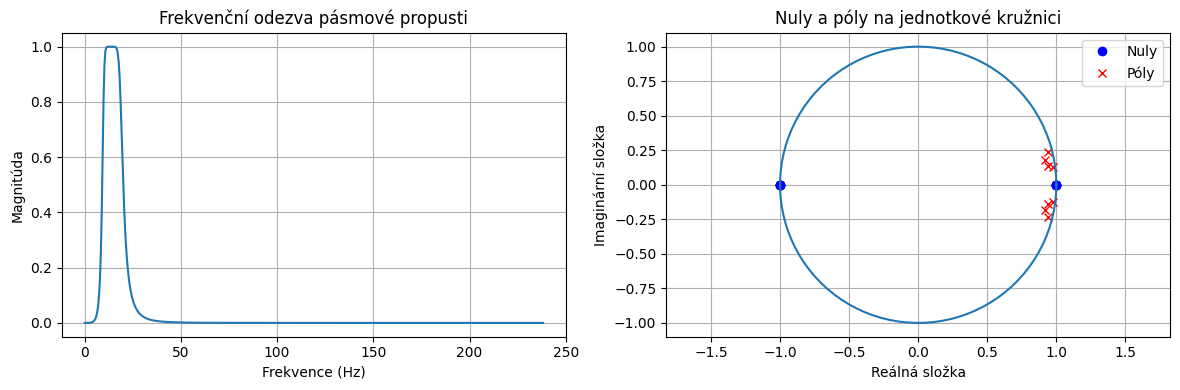

In [6]:
%matplotlib inline
###################################################################################################

# Definice parametrú Bandpass filtru
lowcut = 10
highcut = 20
order = 4

# Návrh pásmové propusti pomocí scipy.butter
b, a = signal.butter(order, [lowcut, highcut], btype='band', fs=fs)

# Výpočet nul a pólů filtru
zeros, poles, _ = signal.tf2zpk(b, a)

# Výpočet frekvenční odezvy filtru
w, h = signal.freqz(b, a, fs=fs)
frequencies = w * 6 / (2 * np.pi)

# Vykreslení frekvenční odezvy pásmové propusti
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(frequencies, abs(h))
plt.title('Frekvenční odezva pásmové propusti')
plt.xlabel('Frekvence (Hz)')
plt.ylabel('Magnitúda')
plt.grid(True)

# Vykreslení nul a pólů na jednotkové kružnici
plt.subplot(1, 2, 2)
plt.plot(np.real(zeros), np.imag(zeros), 'bo', label='Nuly')
plt.plot(np.real(poles), np.imag(poles), 'rx', label='Póly')
plt.plot(np.cos(np.linspace(0, 2 * np.pi, 100)), np.sin(np.linspace(0, 2 * np.pi, 100)))
plt.axis('equal')
plt.title('Nuly a póly na jednotkové kružnici')
plt.xlabel('Reálná složka')
plt.ylabel('Imaginární složka')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

###################################################################################################

  b) [1b] Použijte navržený filtr na nahraný signál. Pokud máte navržený klasický filtr, proveďte filtrování z obou stran, abyste se vyhnuli fázovému posunu, to za vás zajistí například funkce scipy.signal.filtfilt. Vykreslete původní a vyfiltrovaný signál v časové doméně a spočítejte a zobrazte jejich spektra.


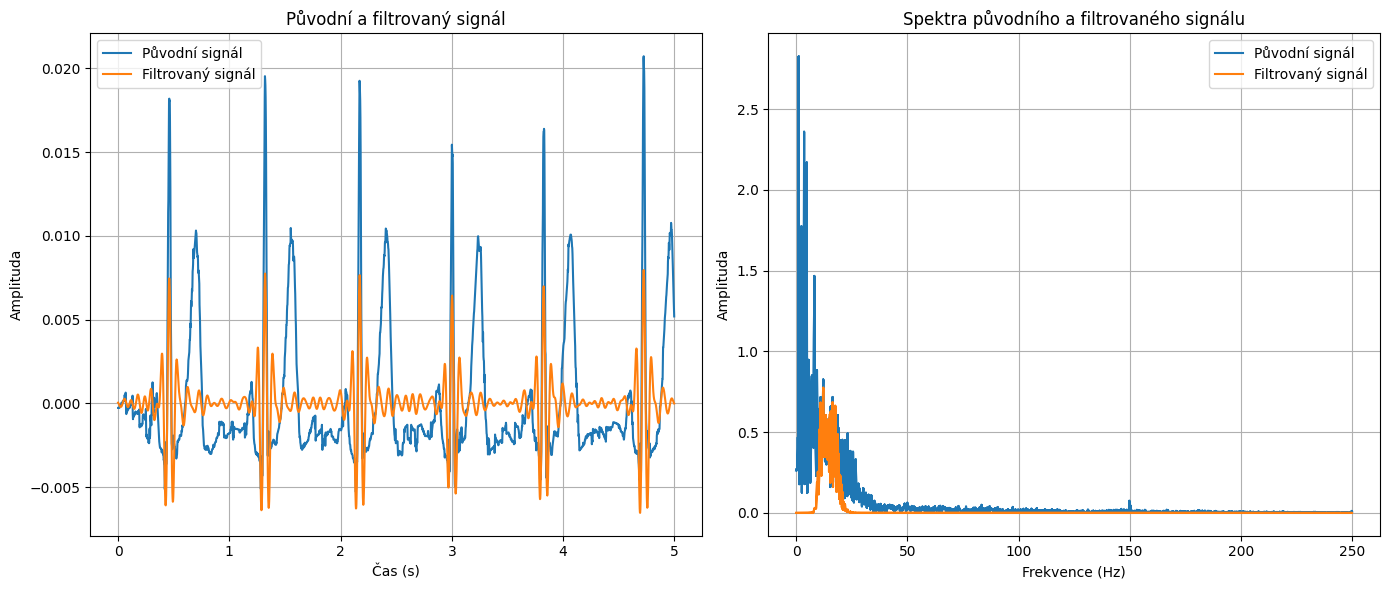

In [7]:
%matplotlib inline
###################################################################################################

# Definice parametrů filtru pásmové propusti
lowcut = 10
highcut = 20
order = 4

# Výpočet Nyquistovy frekvence
nyquist = 0.5 * fs

# Kontrola a úprava kritických frekvencí
if lowcut >= nyquist:
    lowcut = nyquist - 1
if highcut >= nyquist:
    highcut = nyquist - 1

# Návrh filtru pásmové propusti
b, a = signal.butter(order, [lowcut, highcut], btype='band', fs=fs)

# Filtrace signálu pásmovou propustí
filtered_signal = signal.filtfilt(b, a, segment)

# Vytvoření časové osy
time = np.arange(segment.size) / fs

# Výpočet frekvenční osy pro spektra
freq = np.fft.fftfreq(segment.size, 1/fs)

# Vytvoření grafu s původním a filtrovaným signálem v časové doméně
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Výpočet spekter původního a filtrovaného signálu
original_spectrum = np.abs(np.fft.fft(segment))
filtered_spectrum = np.abs(np.fft.fft(filtered_signal))

# Graf původního a filtrovaného signálu v časové doméně
axs[0].plot(time, segment, label='Původní signál')
axs[0].plot(time, filtered_signal, label='Filtrovaný signál')
axs[0].set_title('Původní a filtrovaný signál')
axs[0].set_xlabel('Čas (s)')
axs[0].set_ylabel('Amplituda')
axs[0].legend()
axs[0].grid(True)

# Graf spekter původního a filtrovaného signálu
axs[1].plot(np.abs(freq), original_spectrum, label='Původní signál')
axs[1].plot(np.abs(freq), filtered_spectrum, label='Filtrovaný signál')
axs[1].set_title('Spektra původního a filtrovaného signálu')
axs[1].set_xlabel('Frekvence (Hz)')
axs[1].set_ylabel('Amplituda')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

###################################################################################################

  c) [1b] Okomentujte rozdíl mezi filtrovaným a nefiltrovaným signálem a jejich spektry. Pokud bychom použili filtrování pouze z jedné strany (obyčejnou konvoluci), jaké je teoreticky největší posunutí ve vzorcích, které se může objevit a proč?



Filtrovaný signál obsahuje změny v obsahu informací a redukovaný šum ve srovnání s nefiltrovaným signálem. Pokud bychom aplikovali filtraci z jedné strany, největší posun v datech by byl o délku filtru minus jedna, protože konvoluce se zaměřuje pouze na body, kde se filtr překrývá s vstupním signálem.

### 4.4. [3b] Vytvořte detektor QRS v časové doméně. Detekované QRS komplexy uložte do vhodné struktury a zároveň zobrazte graf v časové ose se zvýrazněnými QRS detekcemi.



   a) [1b] Detekujte QRS v převzorkovaném vyfiltrovaném signálu pomocí tresholdu (prahu). Pro tuto detekci musíte nejdříve získat vzorek jednoho QRS ze signálu, spočítat si maximální amplitudu a jako treshold vzít vámi určené procento této hodnoty. **Dávejte pozor na možnost otočeného QRS v signálu.** Do vykresleného signálu s detekcemi vykreslete i čáru udávající použitý treshold.

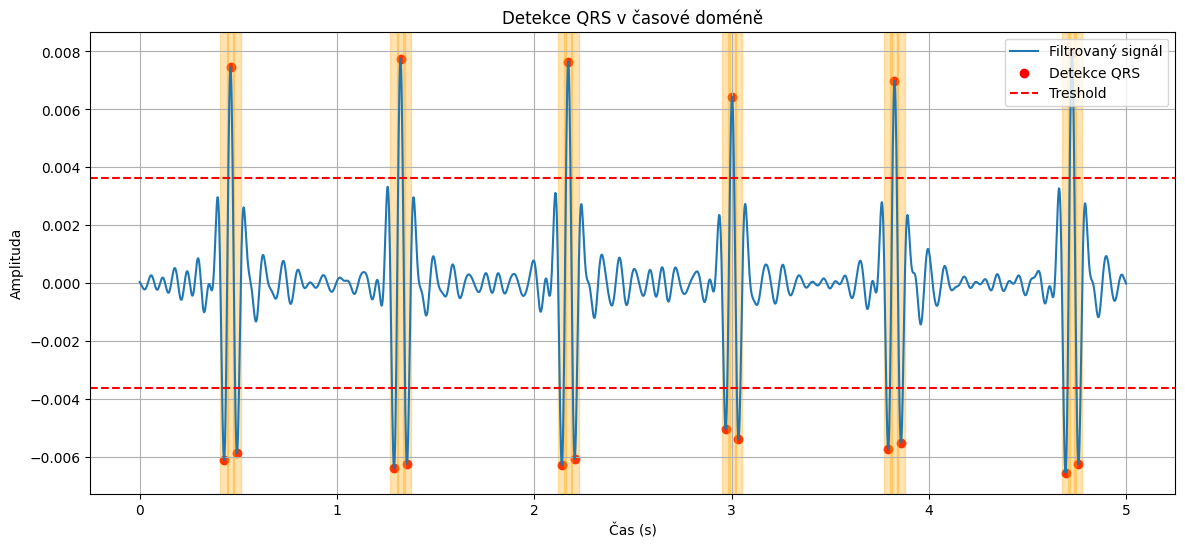

In [8]:
%matplotlib inline
###################################################################################################

# Definice indexu vzorku QRS a velikosti okna
QRS_sample_index = 200
window_size = 10

# Extrahování vzorku kolem identifikovaného QRS komplexu
QRS_sample = filtered_signal[QRS_sample_index - window_size: QRS_sample_index + window_size]

# Výpočet maximální amplitudy a stanovení prahů
max_amplitude = np.max(np.abs(QRS_sample))
threshold_percentage_above = 0.9
threshold_percentage_below = -0.9

# Výpočet prahů pro detekci QRS
threshold_above = threshold_percentage_above * max_amplitude
threshold_below = threshold_percentage_below * max_amplitude

# Detekce QRS pomocí prahů
detected_indices_above = []
detected_indices_below = []
for i in range(1, len(filtered_signal) - 1):
    if filtered_signal[i] > threshold_above and filtered_signal[i] > filtered_signal[i - 1] and \
            filtered_signal[i] > filtered_signal[i + 1]:
        detected_indices_above.append(i)
    elif filtered_signal[i] < threshold_below and filtered_signal[i] < filtered_signal[i - 1] and \
            filtered_signal[i] < filtered_signal[i + 1]:
        detected_indices_below.append(i)

# Vykreslení signálu s detekcí QRS a zvýrazněním detekcí obdélníky
plt.figure(figsize=(14, 6))
plt.plot(time, filtered_signal, label='Filtrovaný signál')
plt.scatter(time[detected_indices_above], filtered_signal[detected_indices_above], color='red', label='Detekce QRS')
plt.scatter(time[detected_indices_below], filtered_signal[detected_indices_below], color='red')
plt.axhline(y=threshold_above, color='red', linestyle='--', label='Treshold')
plt.axhline(y=threshold_below, color='red', linestyle='--')
plt.title('Detekce QRS v časové doméně')
plt.xlabel('Čas (s)')
plt.ylabel('Amplituda')
plt.legend()
plt.grid(True)

# Zvýraznění detekcí QRS pomocí obdélníků
for idx in detected_indices_above:
    plt.axvspan(time[idx - window_size], time[idx + window_size], color='orange', alpha=0.3)
for idx in detected_indices_below:
    plt.axvspan(time[idx - window_size], time[idx + window_size], color='orange', alpha=0.3)

plt.show()

###################################################################################################

b) [2b] Detekujte QRS v signálu pomocí autokorelace v převzorkovaném nefiltrovaném signálu. Pro tuto detekci musíte nejdříve získat vzorek jednoho QRS ze signálu. Dále budete autokorelovat signál právě s tímto výstřižkem. QRS se budou nacházet na místech, kde vám budou vycházet vysoké hodnoty korelace. Do vykresleného signálu s detekcemi zaznačte i vámi zvolený výstřižek.

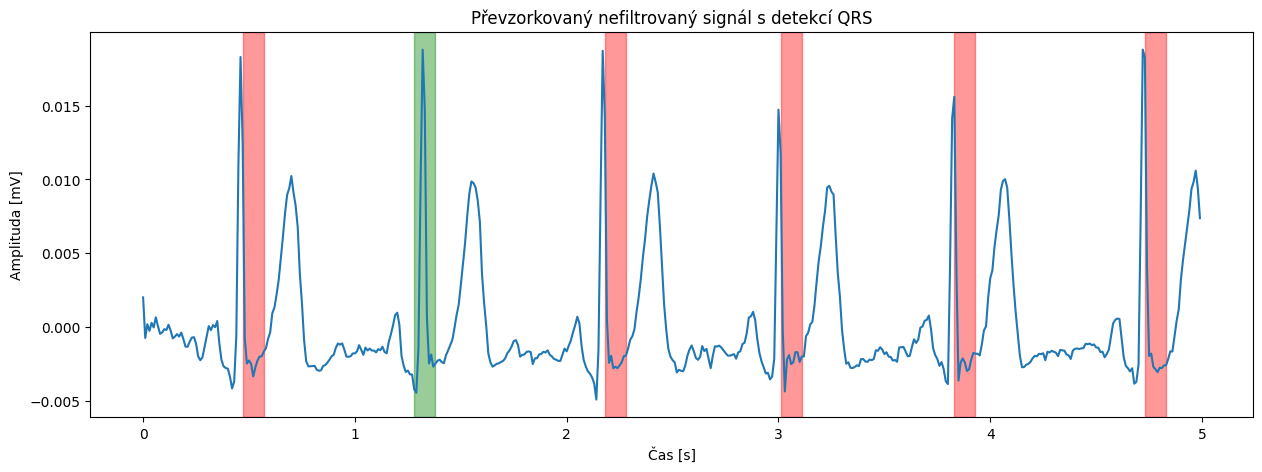

In [9]:
%matplotlib inline
###################################################################################################

# Převzorkování signálu
resampled_segment = signal.resample(segment, int(len(segment) * resampled_fs / fs))

# Definice rozsahu vzorku QRS (upravte podle potřeby)
qrs_start = int(1.28 * resampled_fs)
qrs_end = int(1.38 * resampled_fs)

# Získání vzorku jednoho QRS z signálu
qrs_template = resampled_segment[qrs_start:qrs_end]

# Autokorelace signálu s QRS vzorkem
autocorr = np.correlate(resampled_segment, qrs_template, mode='same')

# Nastavení práhu pro detekci peaků
threshold = 0.7 * np.max(autocorr)  # Upravte tento práh podle potřeby

# Najděte peaky v signálu autokorelace
peaks, _ = find_peaks(autocorr, height=threshold)

# Vykreslení signálu s detekovanými QRS komplexy
plt.figure(figsize=(15, 5))
plt.plot(np.arange(len(resampled_segment)) / resampled_fs, resampled_segment)
plt.xlabel('Čas [s]')
plt.ylabel('Amplituda [mV]')
plt.title('Převzorkovaný nefiltrovaný signál s detekcí QRS')

# Zvýraznění zvoleného výstřižku
plt.axvspan(qrs_start / resampled_fs, qrs_end / resampled_fs, color='g', alpha=0.4)

# Zvýraznění všech detekovaných QRS komplexů kromě již označeného
for peak in peaks:
    if qrs_start <= peak <= qrs_end:
        continue
    plt.axvspan(peak / resampled_fs, (peak + len(qrs_template)) / resampled_fs, color='r', alpha=0.4)

plt.show()

###################################################################################################

### 4.5. [3.5b] Vytvořte detektor QRS v frekvenční doméně a detekované QRS zakreslete jako v předchozí úloze 4.4

a) [2b] Detekujte QRS pomocí použití spektrogramu. Spočítejte a zobrazte spektrogram nahraného převzorkovaného filtrovaného signálu. Použijte parametry, `hop_size=120ms`a `window_len=200ms`, popřípadě si zkuste s těmito parametry pohrát. Spektrogram dále normalizujte v čase. Spočítejte sumy energie spektra pro jednotlivé časové biny. Dále vytvořte práh podle hodnoty energie spektra u prvního vámi zvoleného QRS komplexu. Tento práh použijte pro detekci zbylých QRS komplexů v signálu.

In [10]:
# Zde napište váš kód

b) [1b] Detekujte QRS pomocí použití obálek a Hilbertovy transformace.

Hilbertova transformace je spočítaná podle následujícího vzorce

$x_a = F^{-1}(F(x) 2U) = x + i y,$

kde F je Fourierova transformace a $F^{-1}$ je její zpětná varianta. $U$ je Heavisideova funkce neboli funkce jednotkového skoku, která je definována: $U(x):$

\begin{cases}
      0.5 & x=0 \\
      1 & 0<x<\frac{N}{2} \text{ pro  $N$  liché} \\
      0.5 & x=\frac{N}{2} \text{ pro  $N$  liché} \\
      1 & 0<x\le\frac{N}{2} \text{ pro  $N$  sudé} \\
      0 & jinak
\end{cases}

kde $N$ je počet koeficientů Fourierovy transformace - pokud není určeno jinak, je to počet vzorků signálu.

Jinými slovy obálku spočítate tak, že:

* Spočítáte FFT $F$ na filtrovaném a převzorkovaném signálu
* Vynulujete pravou symetrickou část spektra
* Levou část spektra vynasobíte 2 kromě prvního a prostředního binu (při sudém počtu frekvenčních binů).
* Provedete zpětnou FFT $F^{-1}$

Abyste získali obálku signálu, je třeba vzít absolutní hodnotu signálu získaného Hilbertovou transformací.

Obálku a signál vykreslete do jednoho grafu přes sebe, obálka by měla obalovat daný signál.

In [11]:
# Zde napište váš kód

c) [0.5b] Při kterých metodách detekcí QRS nám vadí otočený (flipnutý) signál, při kterých ne a proč?

*Zde napište vaše řešení.*

### 4.6 [2b] Detekce R-R intervalu

In [12]:
# Zde napište váš kód

### 4.7 Bonus

a) Načtěte si signál obsahující fibrilaci FIS.wav. Proveďte na něm filtrace a převzorkování. Poté zkuste použít nějaký QRS detektor. Z detekovaných QRS detekujte R-R intervaly. Porovnejte R-R intervaly pro fibrilaci a klasický signál bez patologie (sinusovy rytmus). Měli byste vidět prudké změny v R-R intervalech a jejich nepravidelnost. Zároveň se vám může stát, že vám některé metody detekce QRS nepodají tak kvalitní výkon jako při sinusovém rytmu.

In [13]:
# Zde napište váš kód

b) Načtěte si signál obsahující komorovou extrasystolu KES.wav. Proveďte na něm filtrace a převzorkování. Spočítejte a zobrazte spektrogram úseku tohoto signálu. Porovnejte spektrogramy vašeho signálu a signálu KES.wav. Měli byste vidět rozšířenou aktivitu na nízkých frekvencích. Dále zobrazte a porovnejte tyto signály v časové doméně. Obsažené komorové extrasystoly by se měly projevit jako zvláštní široké QRS.

In [14]:
# Zde napište váš kód